# Community Impact and Mitigation Economics

This notebook evaluates the local costs and benefits of AI infrastructure development.

The goal is not to determine whether data centers are universally good or bad for communities. Instead, the objective is to estimate how local benefits such as jobs and tax revenue compare with potential resident costs such as electricity price increases, construction disruption, noise, land use, and water consumption.

The central question is:

**What would it cost a developer to offset the short-term community costs created by a large AI infrastructure project?**

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "outputs").exists():
    if (PROJECT_ROOT.parent / "outputs").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
SOURCE_DIR = PROJECT_ROOT / "sources"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SOURCE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.frameon": False,
})

## Model Design

The model uses a simple low, baseline, and high scenario framework.

Benefits are represented through:

- Temporary construction jobs
- Permanent operations jobs
- Indirect and induced employment
- Annual local tax revenue

Costs are represented through:

- Residential electricity price impacts
- Short-term construction disruption
- Noise and visual impact
- Land use concerns
- Water consumption concerns

The notebook then estimates the size of a community mitigation fund required to offset potential resident electricity bill increases.

This is a first-pass framework, not a full welfare model.

In [3]:
community_inputs = pd.DataFrame({
    "impact_type": [
        "Construction_Jobs",
        "Permanent_Jobs",
        "Indirect_Jobs_Per_Direct",
        "Annual_Local_Tax_Revenue",
        "Electricity_Price_Impact",
        "Worst_Case_Electricity_Impact"
    ],
    "low": [
        1500,
        50,
        6,
        10_000_000,
        10,
        20
    ],
    "baseline": [
        3000,
        125,
        7,
        30_000_000,
        15,
        45
    ],
    "high": [
        5000,
        200,
        8,
        50_000_000,
        20,
        70
    ],
    "unit": [
        "jobs",
        "jobs",
        "multiplier",
        "USD",
        "percent",
        "percent"
    ],
    "notes": [
        "Temporary construction employment",
        "Ongoing direct operations employment",
        "Indirect and induced employment supported per direct operations job",
        "Annual local tax revenue estimate",
        "Typical residential electricity bill increase",
        "Highly constrained grid scenario"
    ]
})

community_inputs

,impact_type,low,baseline,high,unit,notes
0,Construction_Jobs,1500,3000,5000,jobs,Temporary construction employment
1,Permanent_Jobs,50,125,200,jobs,Ongoing direct operations employment
2,Indirect_Jobs_Per_Direct,6,7,8,multiplier,Indirect and induced employment supported per ...
3,Annual_Local_Tax_Revenue,10000000,30000000,50000000,USD,Annual local tax revenue estimate
4,Electricity_Price_Impact,10,15,20,percent,Typical residential electricity bill increase
5,Worst_Case_Electricity_Impact,20,45,70,percent,Highly constrained grid scenario


In [4]:
community_inputs.to_csv(
    SOURCE_DIR / "community_impact_inputs.csv",
    index=False
)

community_inputs

,impact_type,low,baseline,high,unit,notes
0,Construction_Jobs,1500,3000,5000,jobs,Temporary construction employment
1,Permanent_Jobs,50,125,200,jobs,Ongoing direct operations employment
2,Indirect_Jobs_Per_Direct,6,7,8,multiplier,Indirect and induced employment supported per ...
3,Annual_Local_Tax_Revenue,10000000,30000000,50000000,USD,Annual local tax revenue estimate
4,Electricity_Price_Impact,10,15,20,percent,Typical residential electricity bill increase
5,Worst_Case_Electricity_Impact,20,45,70,percent,Highly constrained grid scenario


In [5]:
benefit_rows = []

for scenario in ["low", "baseline", "high"]:

    construction_jobs = (
        community_inputs.loc[
            community_inputs["impact_type"] == "Construction_Jobs",
            scenario
        ].iloc[0]
    )

    permanent_jobs = (
        community_inputs.loc[
            community_inputs["impact_type"] == "Permanent_Jobs",
            scenario
        ].iloc[0]
    )

    multiplier = (
        community_inputs.loc[
            community_inputs["impact_type"] == "Indirect_Jobs_Per_Direct",
            scenario
        ].iloc[0]
    )

    tax_revenue = (
        community_inputs.loc[
            community_inputs["impact_type"] == "Annual_Local_Tax_Revenue",
            scenario
        ].iloc[0]
    )

    total_jobs = (
        permanent_jobs
        + permanent_jobs * multiplier
    )

    benefit_rows.append({
        "scenario": scenario.title(),
        "construction_jobs": construction_jobs,
        "permanent_jobs": permanent_jobs,
        "indirect_jobs": permanent_jobs * multiplier,
        "total_jobs_supported": total_jobs,
        "annual_tax_revenue_usd": tax_revenue
    })

community_benefits = pd.DataFrame(benefit_rows)

community_benefits

,scenario,construction_jobs,permanent_jobs,indirect_jobs,total_jobs_supported,annual_tax_revenue_usd
0,Low,1500,50,300,350,10000000
1,Baseline,3000,125,875,1000,30000000
2,High,5000,200,1600,1800,50000000


In [6]:
community_benefits.to_csv(
    TABLE_DIR / "community_benefits.csv",
    index=False
)

community_benefits

,scenario,construction_jobs,permanent_jobs,indirect_jobs,total_jobs_supported,annual_tax_revenue_usd
0,Low,1500,50,300,350,10000000
1,Baseline,3000,125,875,1000,30000000
2,High,5000,200,1600,1800,50000000


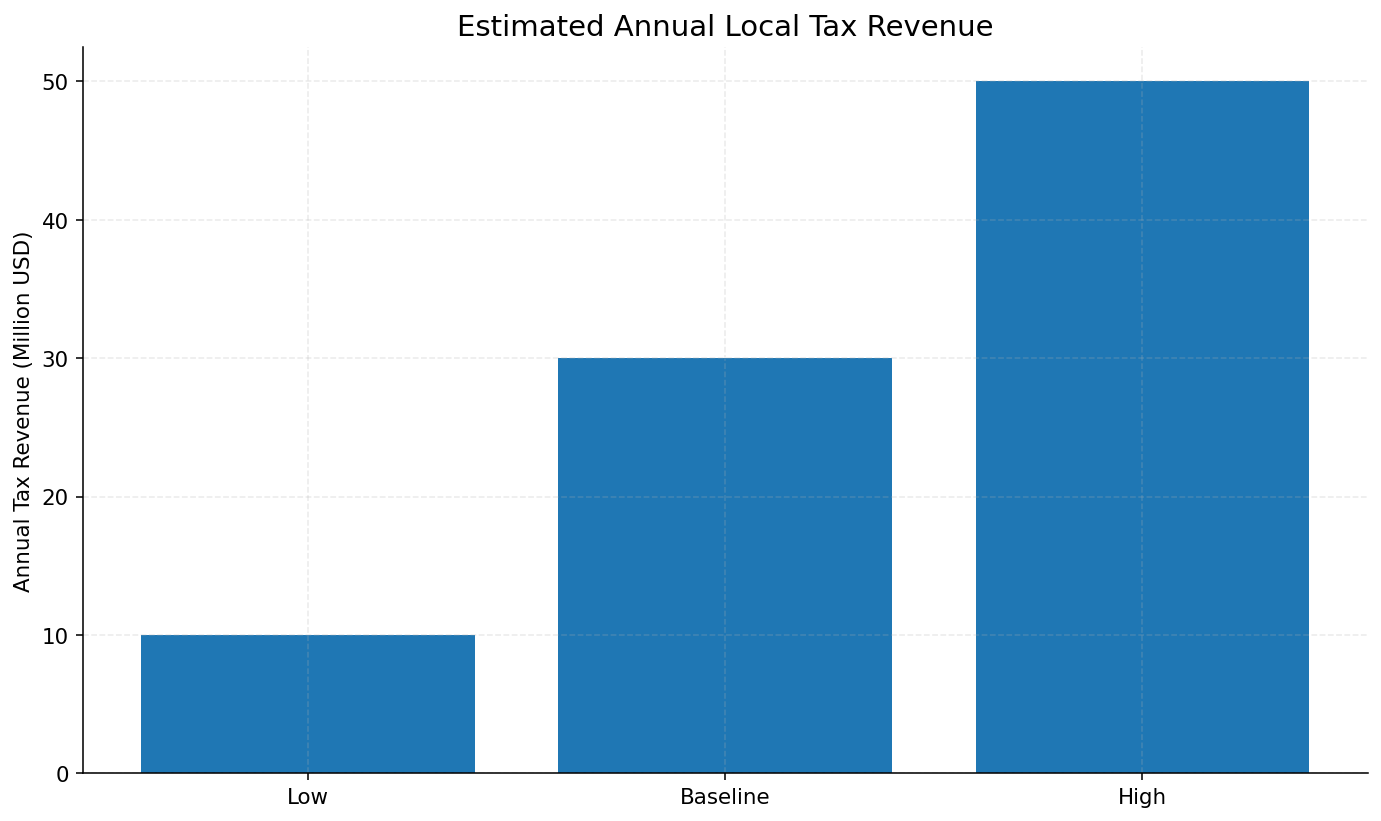

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    community_benefits["scenario"],
    community_benefits["annual_tax_revenue_usd"] / 1_000_000
)

plt.ylabel("Annual Tax Revenue (Million USD)")
plt.title("Estimated Annual Local Tax Revenue")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig8_1_tax_revenue.png",
    bbox_inches="tight"
)

plt.show()

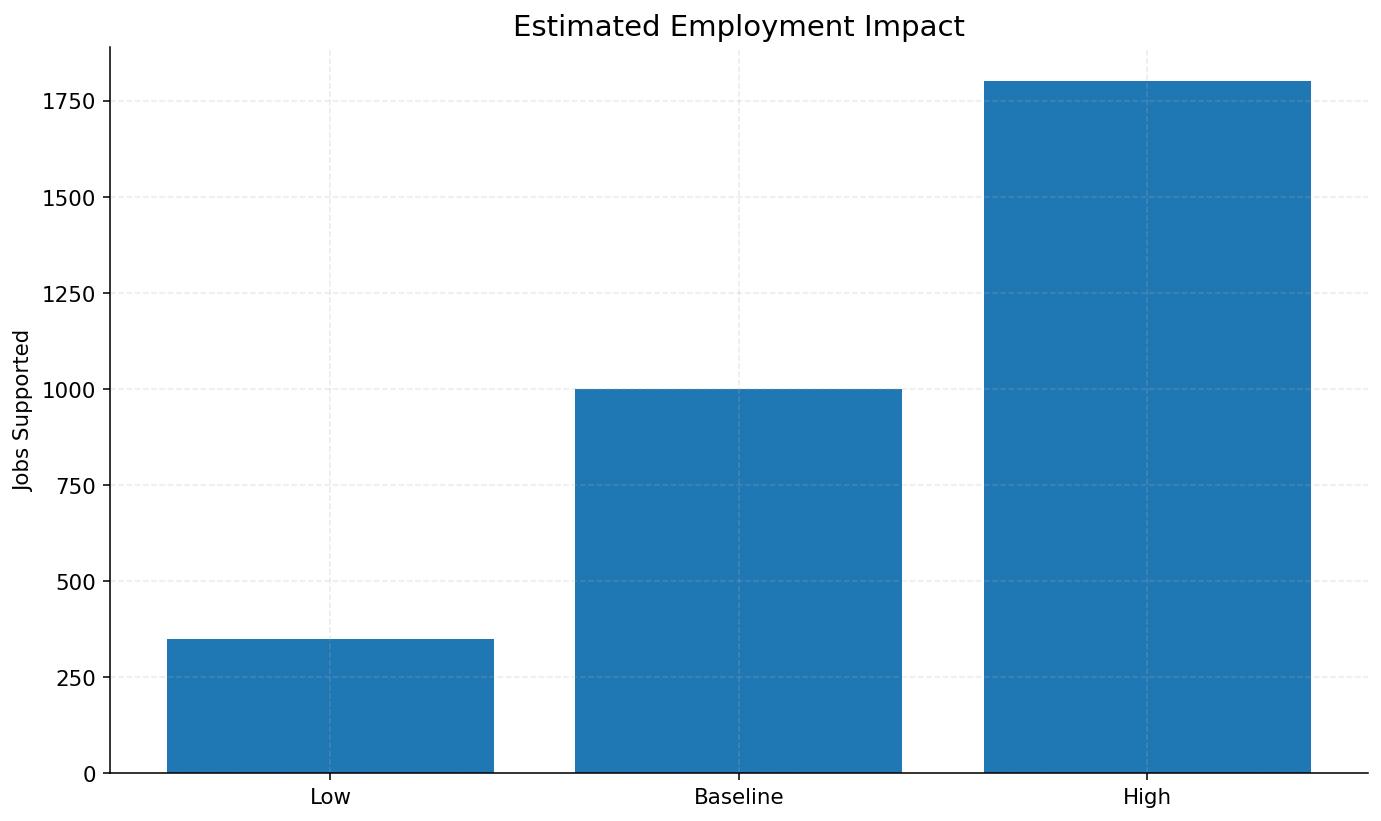

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(
    community_benefits["scenario"],
    community_benefits["total_jobs_supported"]
)

plt.ylabel("Jobs Supported")
plt.title("Estimated Employment Impact")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig8_2_jobs_supported.png",
    bbox_inches="tight"
)

plt.show()

## Residential Electricity Cost Impact

One of the primary concerns surrounding large data center developments is the possibility that local residents may experience higher electricity prices as utilities invest in new infrastructure and generation capacity.

This section estimates the potential annual cost imposed on households under low, baseline, and high electricity price impact scenarios.

In [9]:
households = 50_000

average_monthly_bill_usd = 150

electricity_impact_scenarios = pd.DataFrame({
    "scenario": ["Low", "Baseline", "High"],
    "bill_increase_percent": [10, 15, 20]
})

electricity_impact_scenarios

,scenario,bill_increase_percent
0,Low,10
1,Baseline,15
2,High,20


In [10]:
resident_cost_rows = []

for _, row in electricity_impact_scenarios.iterrows():

    annual_cost_per_household = (
        average_monthly_bill_usd
        * 12
        * row["bill_increase_percent"]
        / 100
    )

    community_cost = (
        annual_cost_per_household
        * households
    )

    resident_cost_rows.append({
        "scenario": row["scenario"],
        "annual_cost_per_household_usd": annual_cost_per_household,
        "annual_community_cost_usd": community_cost
    })

resident_costs = pd.DataFrame(resident_cost_rows)

resident_costs

,scenario,annual_cost_per_household_usd,annual_community_cost_usd
0,Low,180.0,9000000.0
1,Baseline,270.0,13500000.0
2,High,360.0,18000000.0


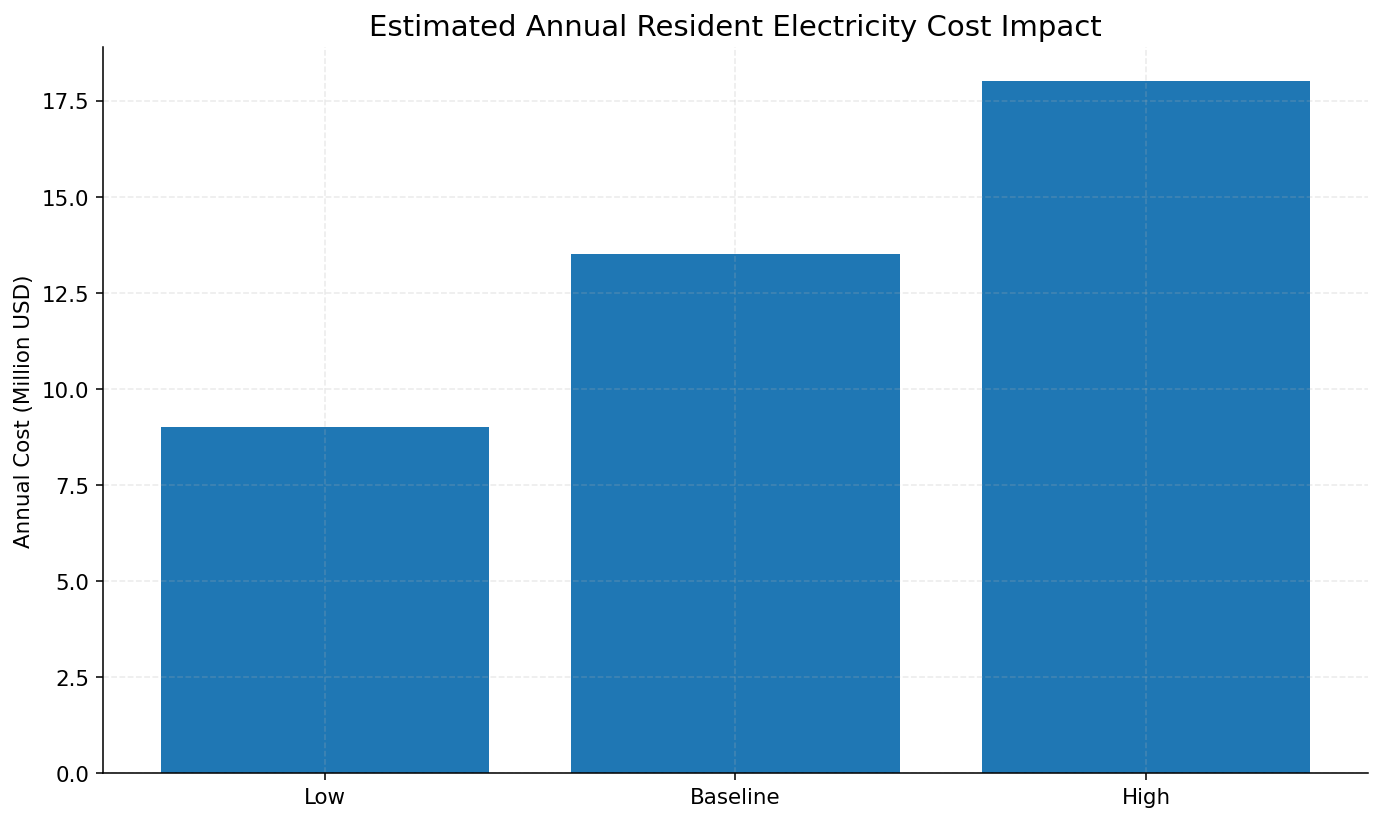

In [11]:
plt.figure(figsize=(10, 6))

plt.bar(
    resident_costs["scenario"],
    resident_costs["annual_community_cost_usd"] / 1_000_000
)

plt.ylabel("Annual Cost (Million USD)")
plt.title("Estimated Annual Resident Electricity Cost Impact")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig8_3_resident_cost_impact.png",
    bbox_inches="tight"
)

plt.show()

## Community Benefits vs Resident Electricity Costs

This section compares estimated annual local tax revenue with estimated annual residential electricity cost impacts.

The purpose is to evaluate whether a community benefit or mitigation fund could offset short-term resident electricity cost increases while still leaving positive fiscal benefits for the local government.

In [12]:
community_tradeoff = community_benefits.merge(
    resident_costs,
    on="scenario",
    how="left"
)

community_tradeoff["net_fiscal_surplus_after_resident_offset_usd"] = (
    community_tradeoff["annual_tax_revenue_usd"]
    - community_tradeoff["annual_community_cost_usd"]
)

community_tradeoff

,scenario,construction_jobs,permanent_jobs,indirect_jobs,total_jobs_supported,annual_tax_revenue_usd,annual_cost_per_household_usd,annual_community_cost_usd,net_fiscal_surplus_after_resident_offset_usd
0,Low,1500,50,300,350,10000000,180.0,9000000.0,1000000.0
1,Baseline,3000,125,875,1000,30000000,270.0,13500000.0,16500000.0
2,High,5000,200,1600,1800,50000000,360.0,18000000.0,32000000.0


In [13]:
community_tradeoff.to_csv(
    TABLE_DIR / "community_impact_tradeoff.csv",
    index=False
)

community_tradeoff

,scenario,construction_jobs,permanent_jobs,indirect_jobs,total_jobs_supported,annual_tax_revenue_usd,annual_cost_per_household_usd,annual_community_cost_usd,net_fiscal_surplus_after_resident_offset_usd
0,Low,1500,50,300,350,10000000,180.0,9000000.0,1000000.0
1,Baseline,3000,125,875,1000,30000000,270.0,13500000.0,16500000.0
2,High,5000,200,1600,1800,50000000,360.0,18000000.0,32000000.0


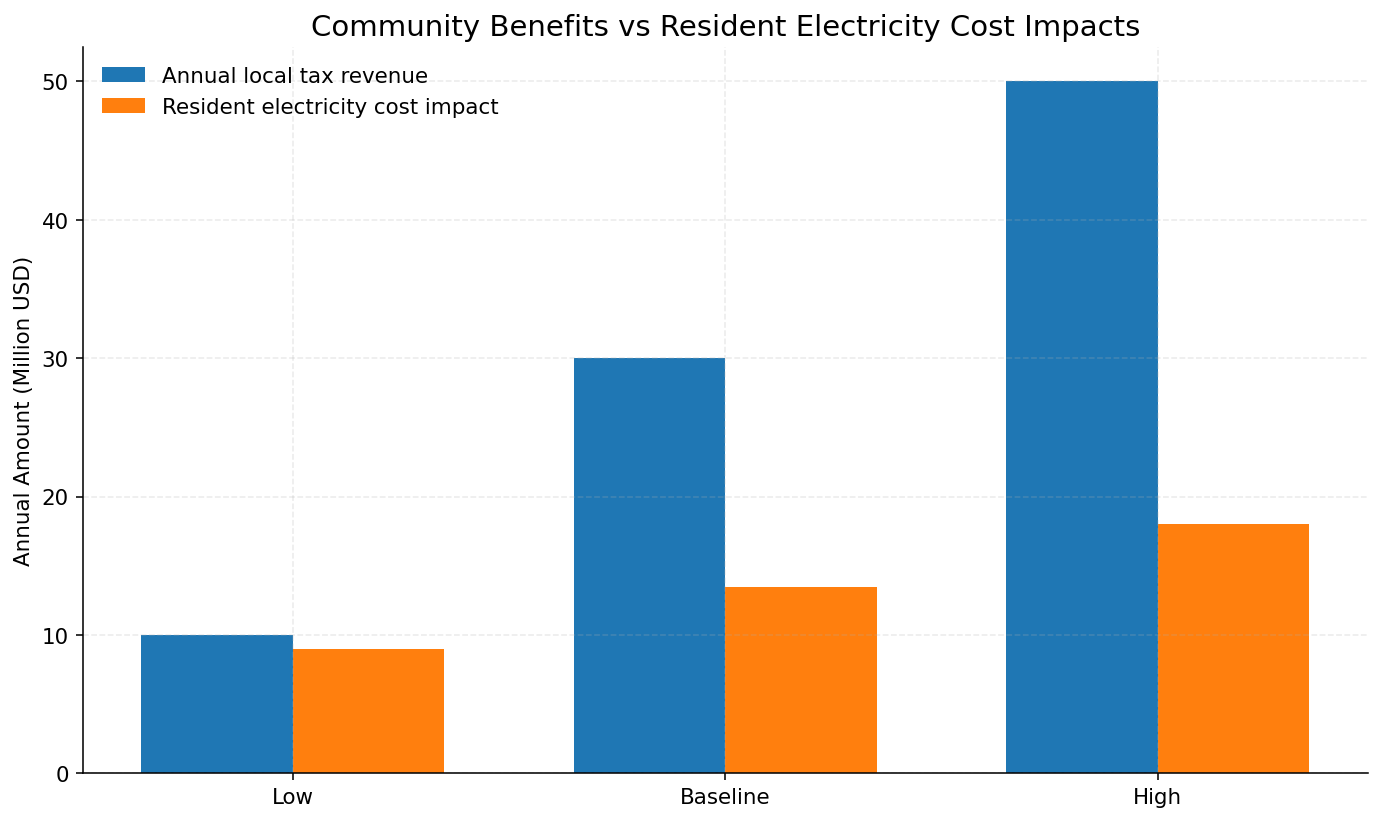

In [14]:
x = np.arange(len(community_tradeoff))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    community_tradeoff["annual_tax_revenue_usd"] / 1_000_000,
    width,
    label="Annual local tax revenue"
)

plt.bar(
    x + width / 2,
    community_tradeoff["annual_community_cost_usd"] / 1_000_000,
    width,
    label="Resident electricity cost impact"
)

plt.xticks(x, community_tradeoff["scenario"])
plt.ylabel("Annual Amount (Million USD)")
plt.title("Community Benefits vs Resident Electricity Cost Impacts")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig8_4_benefits_vs_resident_costs.png",
    bbox_inches="tight"
)

plt.show()

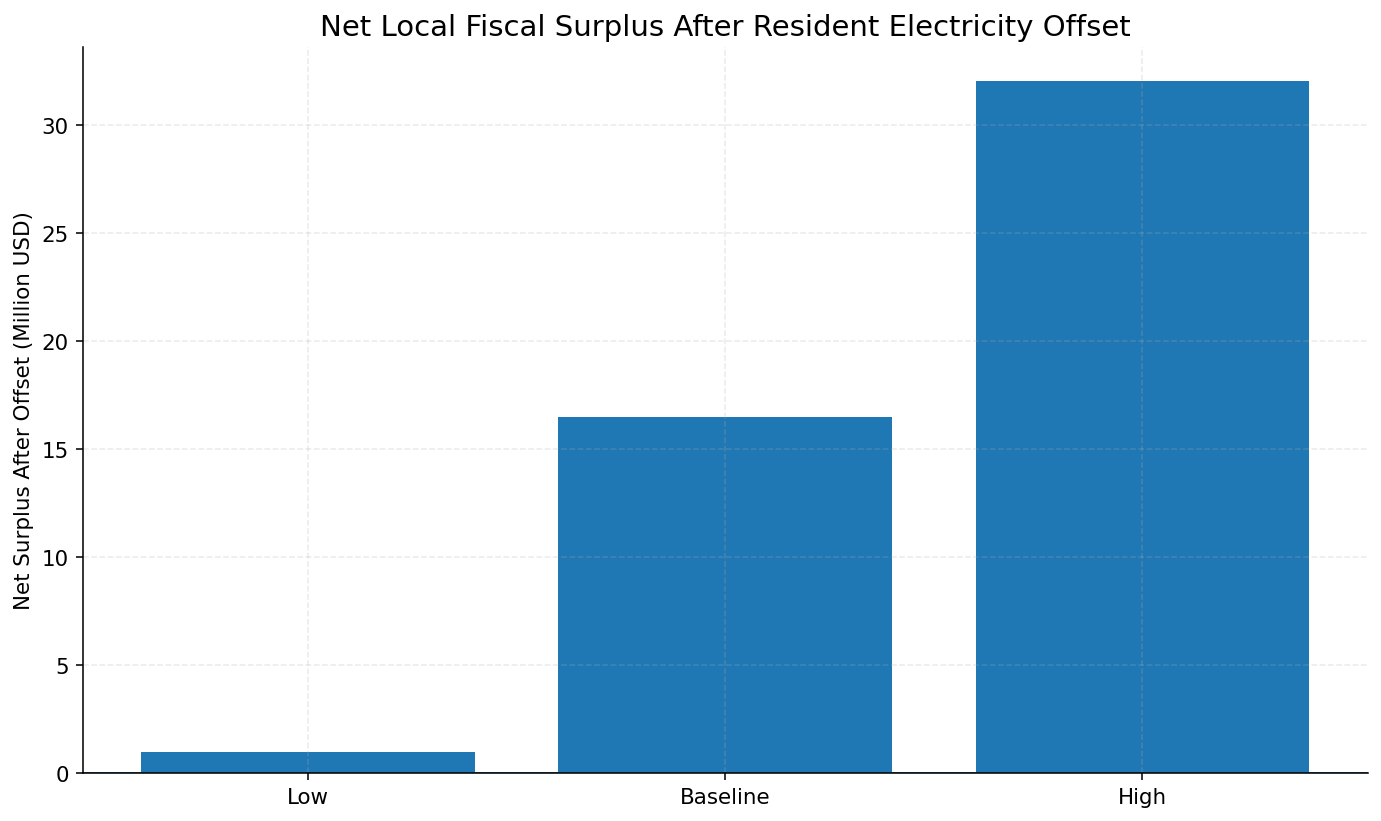

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    community_tradeoff["scenario"],
    community_tradeoff["net_fiscal_surplus_after_resident_offset_usd"] / 1_000_000
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("Net Surplus After Offset (Million USD)")
plt.title("Net Local Fiscal Surplus After Resident Electricity Offset")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig8_5_net_surplus_after_offset.png",
    bbox_inches="tight"
)

plt.show()

## Mitigation Fund Requirement

This section estimates the annual mitigation fund required to fully offset residential electricity bill increases.

The mitigation fund is calculated as the total annual community electricity cost impact.

This does not imply that direct bill credits are the only possible policy response. The same amount could also be allocated toward:

- Residential bill credits
- Community benefit agreements
- Local grid upgrades
- Energy efficiency programs
- Rooftop solar incentives
- Local battery storage programs

In [16]:
mitigation_fund = community_tradeoff[
    [
        "scenario",
        "annual_community_cost_usd",
        "annual_tax_revenue_usd",
        "net_fiscal_surplus_after_resident_offset_usd"
    ]
].copy()

mitigation_fund = mitigation_fund.rename(
    columns={
        "annual_community_cost_usd": "required_mitigation_fund_usd",
        "annual_tax_revenue_usd": "annual_local_tax_revenue_usd"
    }
)

mitigation_fund["mitigation_as_percent_of_tax_revenue"] = (
    mitigation_fund["required_mitigation_fund_usd"]
    / mitigation_fund["annual_local_tax_revenue_usd"]
    * 100
)

mitigation_fund

,scenario,required_mitigation_fund_usd,annual_local_tax_revenue_usd,net_fiscal_surplus_after_resident_offset_usd,mitigation_as_percent_of_tax_revenue
0,Low,9000000.0,10000000,1000000.0,90.0
1,Baseline,13500000.0,30000000,16500000.0,45.0
2,High,18000000.0,50000000,32000000.0,36.0


In [17]:
mitigation_fund.to_csv(
    TABLE_DIR / "community_mitigation_fund.csv",
    index=False
)

mitigation_fund

,scenario,required_mitigation_fund_usd,annual_local_tax_revenue_usd,net_fiscal_surplus_after_resident_offset_usd,mitigation_as_percent_of_tax_revenue
0,Low,9000000.0,10000000,1000000.0,90.0
1,Baseline,13500000.0,30000000,16500000.0,45.0
2,High,18000000.0,50000000,32000000.0,36.0


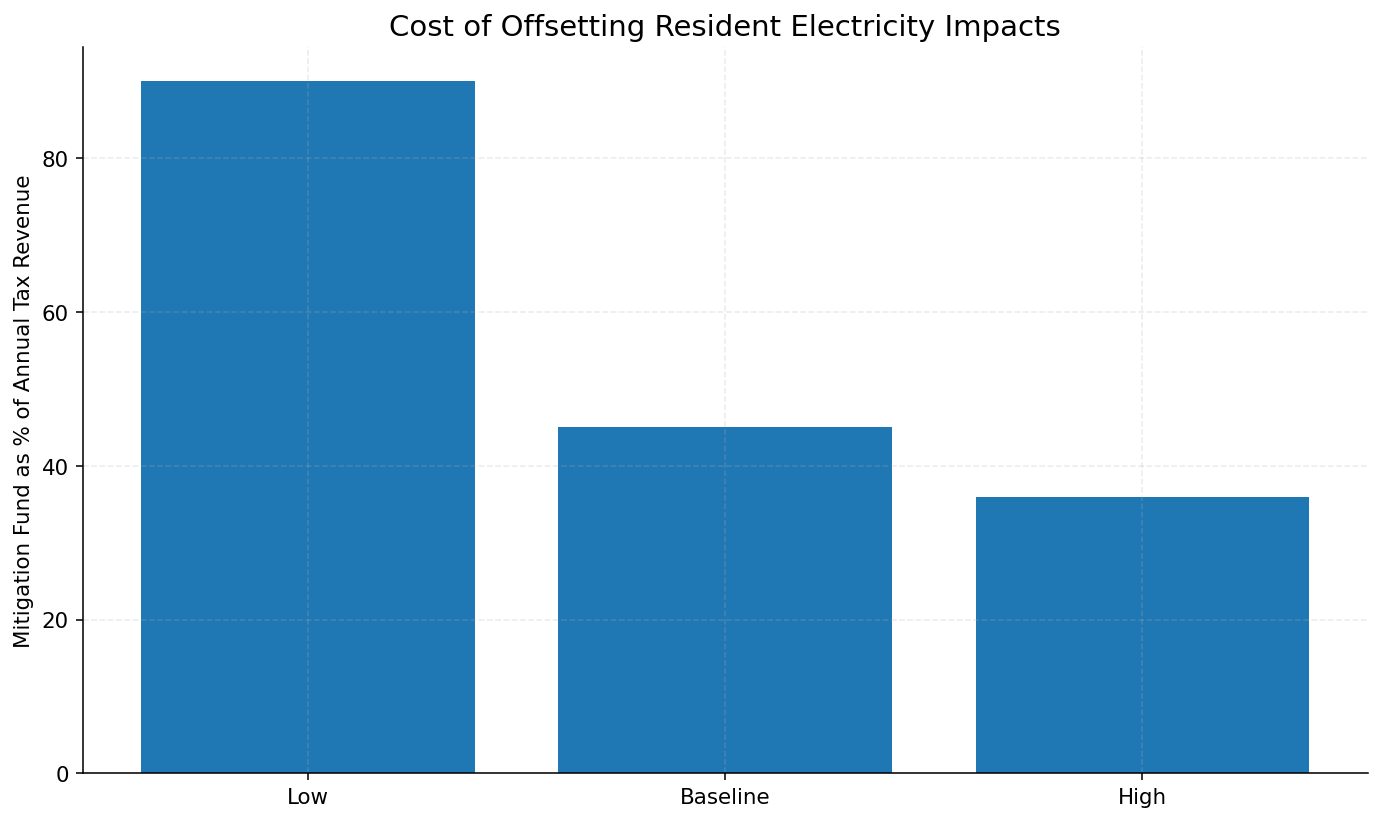

In [18]:
plt.figure(figsize=(10, 6))

plt.bar(
    mitigation_fund["scenario"],
    mitigation_fund["mitigation_as_percent_of_tax_revenue"]
)

plt.ylabel("Mitigation Fund as % of Annual Tax Revenue")
plt.title("Cost of Offsetting Resident Electricity Impacts")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig8_6_mitigation_as_percent_of_tax_revenue.png",
    bbox_inches="tight"
)

plt.show()

## Key Finding

Under the baseline scenario, the estimated resident electricity cost impact can be offset with a mitigation fund that is smaller than the estimated annual local tax revenue generated by the project.

This suggests that a large AI infrastructure project could remain fiscally positive for a local government even after compensating residents for short-term electricity bill impacts.

The broader implication is that community opposition may not only be a political problem. It may also be an infrastructure finance problem.

If developers, utilities, and local governments can design credible mitigation mechanisms, some of the local burdens associated with AI infrastructure development could be reduced without eliminating the economic benefits of the project.

This framework is intentionally simplified. It does not fully model water use, land value impacts, noise exposure, construction disruption, or long-term grid investment costs. Instead, it provides a first-pass method for comparing community benefits with one of the most direct and politically salient costs: higher residential electricity bills.

In [19]:
community_burden = pd.DataFrame({
    "impact": [
        "Electricity Cost",
        "Construction Traffic",
        "Noise",
        "Visual Impact",
        "Land Use",
        "Water Consumption"
    ],
    "severity_score": [
        5,
        4,
        3,
        2,
        3,
        4
    ]
})

community_burden

,impact,severity_score
0,Electricity Cost,5
1,Construction Traffic,4
2,Noise,3
3,Visual Impact,2
4,Land Use,3
5,Water Consumption,4


<BarContainer object of 6 artists>

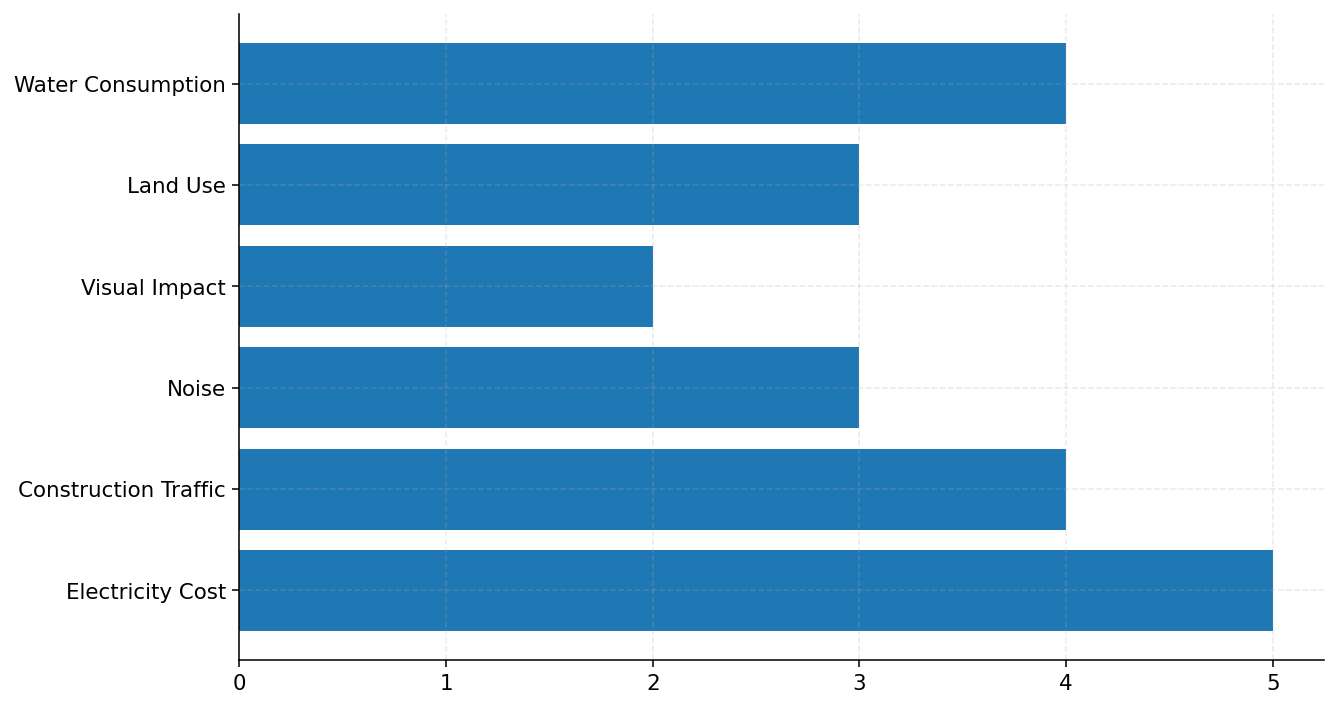

In [20]:
plt.barh(
    community_burden["impact"],
    community_burden["severity_score"]
)

## Community Burden Index

The previous section monetized residential electricity bill impacts.

However, electricity costs are not the only local concern associated with large AI infrastructure projects. Communities may also experience construction traffic, noise, land use changes, water concerns, and visual impacts.

This section creates a simple Community Burden Index to represent non-electricity impacts qualitatively.

Scores range from 1 to 5:

- 1 = Low burden
- 3 = Moderate burden
- 5 = High burden

In [22]:
community_burden = pd.DataFrame({
    "impact": [
        "Electricity Cost",
        "Construction Traffic",
        "Noise",
        "Visual Impact",
        "Land Use",
        "Water Consumption"
    ],
    "severity_score": [
        5,
        4,
        3,
        2,
        3,
        4
    ],
    "possible_mitigation": [
        "Bill credits or energy rebates",
        "Road improvements and construction scheduling",
        "Noise barriers and setback requirements",
        "Landscaping and visual screening",
        "Zoning agreements and community land-use planning",
        "Water recycling and closed-loop cooling"
    ]
})

community_burden

,impact,severity_score,possible_mitigation
0,Electricity Cost,5,Bill credits or energy rebates
1,Construction Traffic,4,Road improvements and construction scheduling
2,Noise,3,Noise barriers and setback requirements
3,Visual Impact,2,Landscaping and visual screening
4,Land Use,3,Zoning agreements and community land-use planning
5,Water Consumption,4,Water recycling and closed-loop cooling


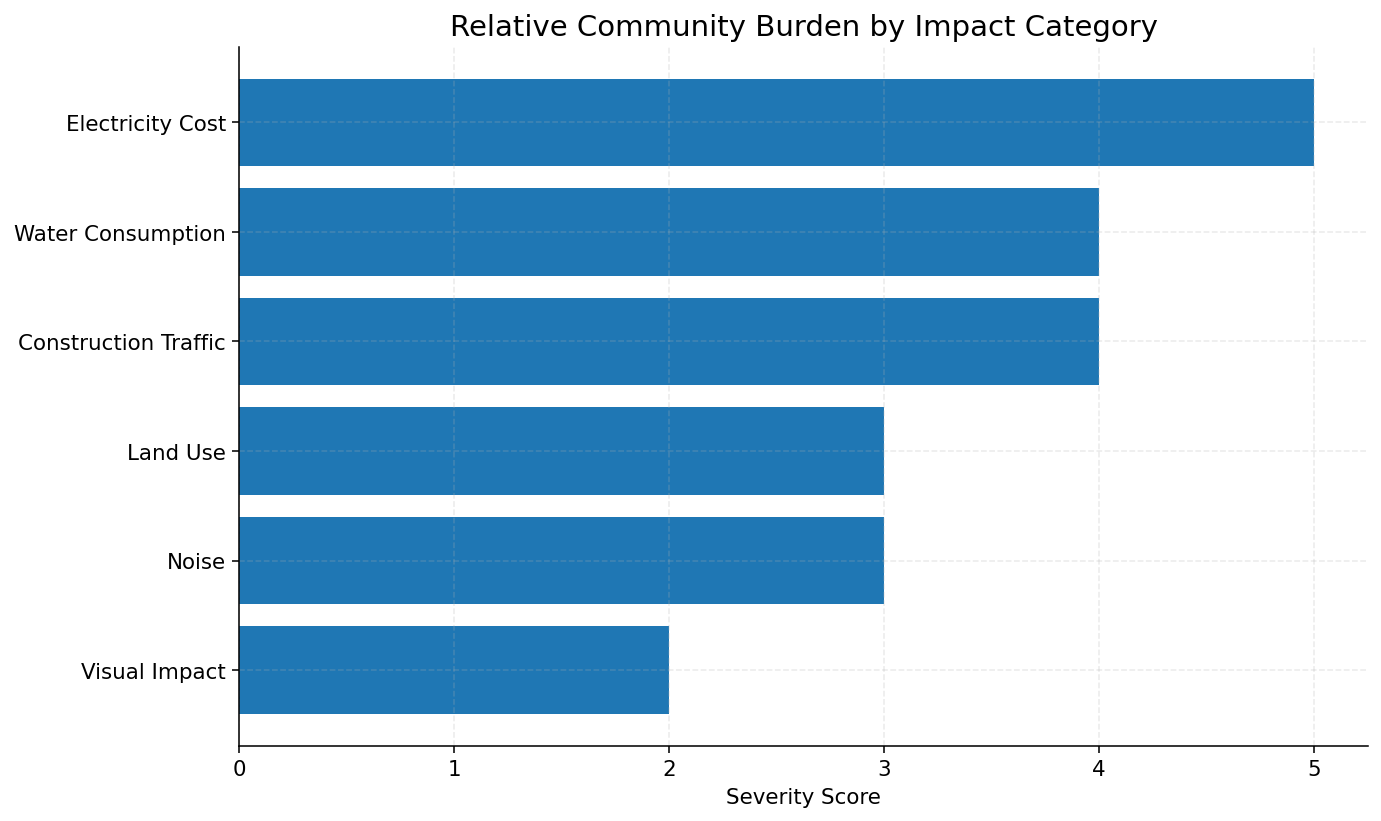

In [23]:
community_burden_sorted = community_burden.sort_values(
    "severity_score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    community_burden_sorted["impact"],
    community_burden_sorted["severity_score"]
)

plt.xlabel("Severity Score")
plt.title("Relative Community Burden by Impact Category")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig8_7_community_burden_index.png",
    bbox_inches="tight"
)

plt.show()

In [24]:
community_burden.to_csv(
    TABLE_DIR / "community_burden_index.csv",
    index=False
)

community_burden

,impact,severity_score,possible_mitigation
0,Electricity Cost,5,Bill credits or energy rebates
1,Construction Traffic,4,Road improvements and construction scheduling
2,Noise,3,Noise barriers and setback requirements
3,Visual Impact,2,Landscaping and visual screening
4,Land Use,3,Zoning agreements and community land-use planning
5,Water Consumption,4,Water recycling and closed-loop cooling


## Mitigation Portfolio

The mitigation fund does not need to be spent only on direct bill credits.

A developer, utility, or local government could create a mitigation portfolio that combines direct resident compensation with infrastructure and quality-of-life investments.

This section estimates a baseline mitigation package designed to offset electricity bill impacts while also addressing non-electricity community burdens.

In [25]:
mitigation_options = pd.DataFrame({
    "mitigation": [
        "Electricity Bill Credits",
        "Community Benefit Fund",
        "Grid Upgrades",
        "Local Solar Program",
        "Battery Storage",
        "Road Improvements",
        "Noise Barriers"
    ],
    "estimated_cost_usd": [
        13_500_000,
        10_000_000,
        20_000_000,
        8_000_000,
        15_000_000,
        5_000_000,
        2_000_000
    ],
    "impact_addressed": [
        "Electricity cost burden",
        "General community compensation",
        "Grid reliability and capacity",
        "Long-term residential energy savings",
        "Peak demand and resilience",
        "Construction traffic and local infrastructure",
        "Noise exposure"
    ]
})

mitigation_options

,mitigation,estimated_cost_usd,impact_addressed
0,Electricity Bill Credits,13500000,Electricity cost burden
1,Community Benefit Fund,10000000,General community compensation
2,Grid Upgrades,20000000,Grid reliability and capacity
3,Local Solar Program,8000000,Long-term residential energy savings
4,Battery Storage,15000000,Peak demand and resilience
5,Road Improvements,5000000,Construction traffic and local infrastructure
6,Noise Barriers,2000000,Noise exposure


In [26]:
baseline_tax_revenue = community_tradeoff.loc[
    community_tradeoff["scenario"] == "Baseline",
    "annual_tax_revenue_usd"
].iloc[0]

baseline_resident_cost = community_tradeoff.loc[
    community_tradeoff["scenario"] == "Baseline",
    "annual_community_cost_usd"
].iloc[0]

selected_mitigation = mitigation_options[
    mitigation_options["mitigation"].isin([
        "Electricity Bill Credits",
        "Road Improvements",
        "Noise Barriers"
    ])
].copy()

total_mitigation_cost = selected_mitigation[
    "estimated_cost_usd"
].sum()

remaining_surplus_after_mitigation = (
    baseline_tax_revenue
    - total_mitigation_cost
)

mitigation_portfolio_summary = pd.DataFrame({
    "metric": [
        "Baseline annual local tax revenue",
        "Baseline resident electricity cost impact",
        "Selected mitigation portfolio cost",
        "Remaining surplus after mitigation"
    ],
    "value_usd": [
        baseline_tax_revenue,
        baseline_resident_cost,
        total_mitigation_cost,
        remaining_surplus_after_mitigation
    ]
})

mitigation_portfolio_summary

,metric,value_usd
0,Baseline annual local tax revenue,30000000.0
1,Baseline resident electricity cost impact,13500000.0
2,Selected mitigation portfolio cost,20500000.0
3,Remaining surplus after mitigation,9500000.0


In [27]:
mitigation_options.to_csv(
    TABLE_DIR / "community_mitigation_options.csv",
    index=False
)

mitigation_portfolio_summary.to_csv(
    TABLE_DIR / "community_mitigation_portfolio_summary.csv",
    index=False
)

mitigation_portfolio_summary

,metric,value_usd
0,Baseline annual local tax revenue,30000000.0
1,Baseline resident electricity cost impact,13500000.0
2,Selected mitigation portfolio cost,20500000.0
3,Remaining surplus after mitigation,9500000.0


## Community Benefits vs Mitigation Package

This section compares baseline local tax revenue, resident electricity cost impacts, and the estimated cost of a selected mitigation portfolio.

The objective is to evaluate whether a data center project could fund community mitigation while still generating positive local fiscal value.

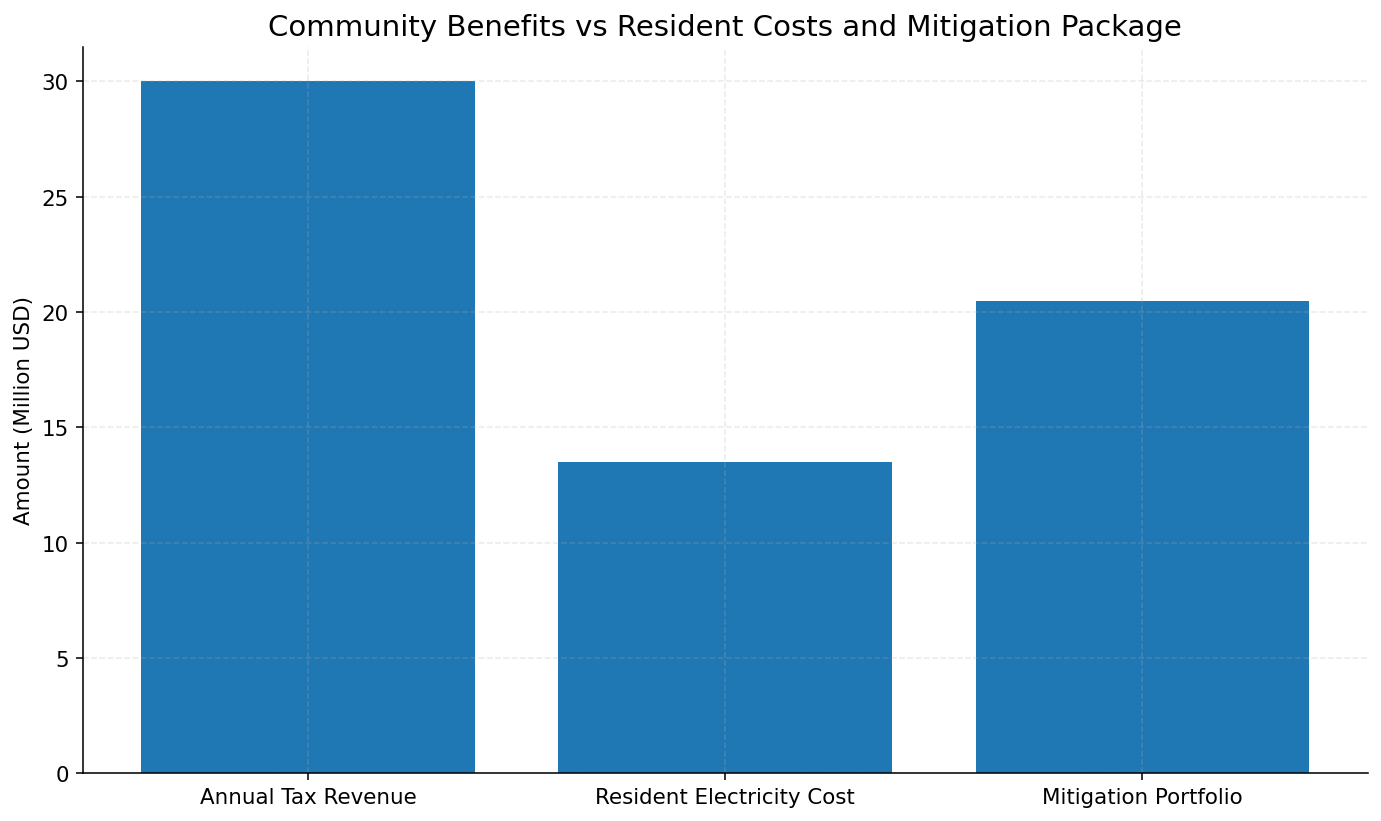

In [28]:
mitigation_comparison = pd.DataFrame({
    "category": [
        "Annual Tax Revenue",
        "Resident Electricity Cost",
        "Mitigation Portfolio"
    ],
    "amount_usd": [
        baseline_tax_revenue,
        baseline_resident_cost,
        total_mitigation_cost
    ]
})

plt.figure(figsize=(10, 6))

plt.bar(
    mitigation_comparison["category"],
    mitigation_comparison["amount_usd"] / 1_000_000
)

plt.ylabel("Amount (Million USD)")
plt.title("Community Benefits vs Resident Costs and Mitigation Package")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig8_8_community_benefits_vs_mitigation.png",
    bbox_inches="tight"
)

plt.show()

In [29]:
mitigation_comparison.to_csv(
    TABLE_DIR / "community_benefits_vs_mitigation.csv",
    index=False
)

mitigation_comparison

,category,amount_usd
0,Annual Tax Revenue,30000000.0
1,Resident Electricity Cost,13500000.0
2,Mitigation Portfolio,20500000.0


## Final Interpretation

The baseline scenario suggests that a large AI infrastructure project could generate enough local tax revenue to offset modeled residential electricity bill impacts and still fund additional community mitigation.

In this version of the model, the selected mitigation portfolio includes:

- Electricity bill credits
- Road improvements
- Noise barriers

The estimated cost of this portfolio remains below the modeled annual local tax revenue.

This suggests that community opposition may partly reflect a distribution problem rather than a pure net-benefit problem. If local governments, utilities, and developers can credibly return part of the project value to affected residents, AI infrastructure development may become more politically and economically feasible.

The notebook remains a simplified first-pass framework. It does not fully monetize water use, land use, long-term grid investment, property value effects, or health impacts from noise and construction activity.